# OTFLEX Kevin Full 24-Well Workflow (Operation-Based Notebook)

This notebook executes the full experimental sequence directly in notebook cells, without graph traversal.

Execution model here:
- Each workflow action is a separate runnable code cell.
- Parameters are declared at the top of each action cell for easy edits.
- Cells are order-agnostic and can be rearranged.
- If something fails, jump to the teardown cell to leave devices in a safe state.

Edit [kevin_24well_biologic_plan.json](../../data/experiment_plans/kevin_24well_biologic_plan.json) to change well recipes, source wells, and Biologic techniques. Helper code lives in [kevin_24well_Helper_Functions.py](../../src/workflows/kevin_24well_Helper_Functions.py).

## Initial Setup

In [1]:
import asyncio
import json
import subprocess
import sys
import time
from pathlib import Path

# Find repo root so imports from src.* work no matter where notebook launches from.
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    raise RuntimeError("Could not find repository root containing src/")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.adapters.iot_mqtt import (
    PumpMQTT,
    UltraMQTT,
    HeatMQTT,
    ReactorMQTT,
    FurnaceMQTT,
    start_broker_if_needed,
    stop_broker,
    ControllerBeacon,
    _best_effort_all_off,
)
from src.adapters.otflex_adapter import OTFlex
from src.core.opentrons import opentronsClient

print(f"Repo root: {repo_root}")

# Device configs defined directly in this notebook
otflex_cfg = {
    "module": "otflex_runtime.py",
    "controller_ip": "192.168.10.161", # might be on 192.168.10.161, 169.254.179.32
    "deck": {
        "slots": {
            "A1": {"name": "electrode_module", "display": "3 electrodes", "labware": "sdl1_single_electrode_tiprack", "file": "data/labware_definitions/sdl1_single_electrode_tiprack.json", "slot_label": "A1"},
            "A2": {"name": "parallel_electrode_module", "display": "4 electrode tool", "labware": "sdl1_parallel_electrode_tiprack", "file": "data/labware_definitions/sdl1_parallel_electrode_tiprack.json", "slot_label": "A2"},
            "A3": {"name": "trash", "display": "trash", "labware": "opentrons_flex_trash", "slot_label": "A3"},
            "B1": {"name": "auto_reactor", "display": "auto_reactor", "labware": "actuated_reactor", "file": "data/labware_definitions/actuated_reactor.json", "slot_label": "B1"},
            "B2": {"name": "source_plate", "display": "precursor solutions", "labware": "sdl1_11_vials_20mL", "file": "data/labware_definitions/sdl1_11_vials_20mL.json", "slot_label": "B2"},
            "B3": {"name": "sonicator_bath", "display": "sonicator bath", "labware": "nis_2_sonicator_bath", "file": "data/labware_definitions/nis_2_sonicator_bath.json", "slot_label": "B3"},
            "C2": {"name": "vial_cap_storage", "display": "vial cap storage", "labware": "custom_vial_cap_holder", "file": "data/labware_definitions/amlab_96_tiprack_1000ul.json", "slot_label": "C2"},
            "C3": {"name": "tiprack_1000ul", "display": "1000ul tips", "labware": "opentrons_flex_96_tiprack_1000ul", "slot_label": "C3"},
            "D1": {"name": "substrate_tower", "display": "tower of substrates", "labware": "zou_21_wellplate_4500ul", "file": "data/labware_definitions/zou_21_wellplate_4500ul.json", "slot_label": "D1"}
        },
        "pipettes": {"right": {"model": "p1000_single_flex"}}
    }
}

mqtt_cfg = {
    "broker": "192.168.0.100",
    "port": 1883,
    "username": "pyctl-controller",
    "password": "controller",
    "topics": {
        "pumps": "pumps/01",
        "reactor": "reactor/01",
        "furnace": "furnace/01",
        "heat": "heat/01",
        # Keep aligned with MQTT_Demo UltraMQTT base_topic.
        "ultra": "ultra/01",
    },
}

# Critical: flushWell uses OTFlex runtime MQTT helpers, so pass MQTT config into otflex runtime.
otflex_cfg["mqtt"] = mqtt_cfg

opentrons_cfg = {
    "ip": otflex_cfg["controller_ip"],
    "robot": "flex",
}

# Shared runtime objects.
otflex = OTFlex(otflex_cfg, root_dir=repo_root)

beacon = None
pumps = None
ultra = None
heat = None
reactor = None
furnace = None

print("Setup objects created. Run homing cell next, then connect devices.")

Repo root: C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-monorepo
[OTFlex] Loaded module: C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-monorepo\src\core\otflex_runtime.py
Setup objects created. Run homing cell next, then connect devices.


## Home Opentrons Robot First

Run this before any workflow action.

This cell inlines the same approach used by `scripts/home_opentrons.py` (directly using `opentronsClient`), without importing that script.

In [2]:
# Homing params (editable)
homing_params = {
    "ip": opentrons_cfg["ip"],
    "robot": opentrons_cfg["robot"],
}

client = opentronsClient(
    strRobotIP=homing_params["ip"],
    strRobot=homing_params["robot"],
)
client.homeRobot()
print(f"Homed {homing_params['robot']} at {homing_params['ip']}")

Homed flex at 192.168.10.161


## Capture Lab Setup Image (Before Connect)

Run this after homing and before connecting devices.

This uses the same SSH capture flow as the verbose Pi camera notebook:
- connect to Raspberry Pi over SSH
- capture an image with Picamera2
- download to `data/out/images`
- rotate the image 180 degrees
- display the image inline
- remove temporary remote image

SSH port reachable at 192.168.0.101:22
SSH connect attempt 1/3
Lab setup image saved: C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-monorepo\data\out\images\otflex-top_20260514_172903.jpg
Showing rotated image: otflex-top_20260514_172903.jpg


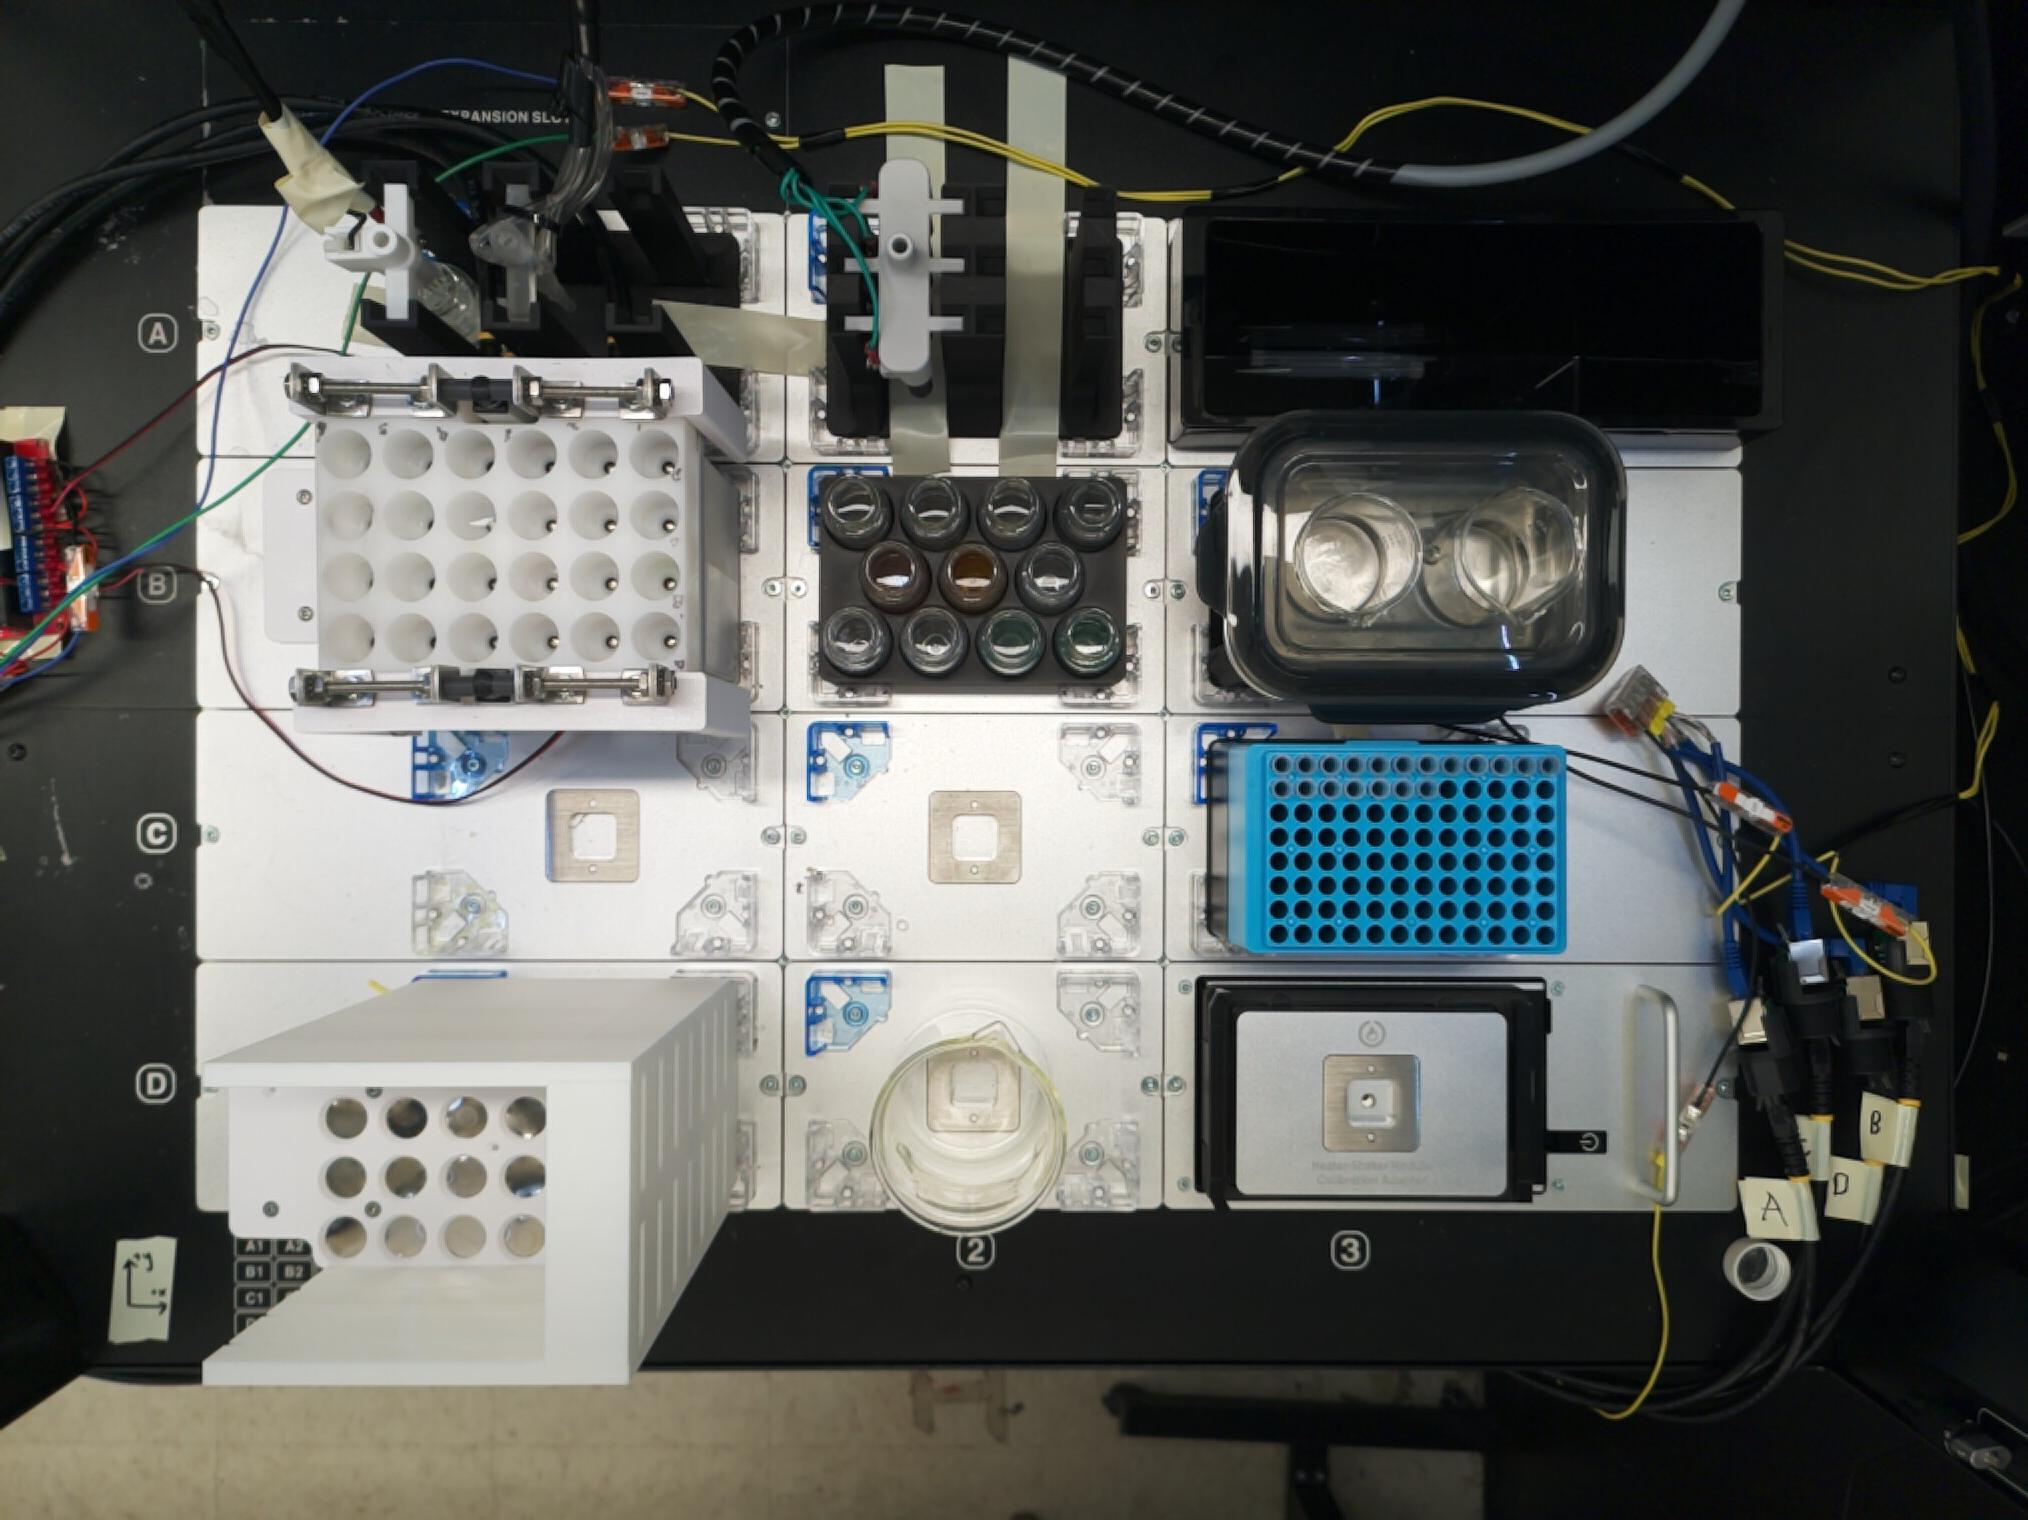

In [11]:
# Camera params (editable)
camera_params = {
    "host": "192.168.0.101",
    "username": "sdl1",
    "password": "1144",
    "ssh_port": 22,
    "connect_timeout_s": 8,
    "connect_retries": 3,
    "remote_capture_dir": "/tmp",
    "warmup_s": 2,
    "rotate_degrees": 180,
}

from datetime import datetime
import socket

try:
    import paramiko
except Exception as exc:
    raise ImportError(
        "paramiko is required for SSH camera capture. Install it in the notebook environment."
    ) from exc

try:
    from PIL import Image as PILImage
    from IPython.display import Image as IPyImage, display
except Exception as exc:
    raise ImportError(
        "Pillow and IPython display are required for rotate/display. Install pillow in the notebook environment."
    ) from exc

out_dir = repo_root / "data" / "out" / "images"
out_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"otflex-top_{timestamp}.jpg"
remote_path = f"{camera_params['remote_capture_dir']}/{filename}"
local_path = out_dir / filename

with socket.create_connection(
    (camera_params["host"], int(camera_params["ssh_port"])),
    timeout=3,
    ):
    pass
print(f"SSH port reachable at {camera_params['host']}:{camera_params['ssh_port']}")

ssh = None
try:
    ssh = paramiko.SSHClient()
    ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())

    for attempt in range(1, int(camera_params["connect_retries"]) + 1):
        try:
            print(f"SSH connect attempt {attempt}/{camera_params['connect_retries']}")
            ssh.connect(
                camera_params["host"],
                port=int(camera_params["ssh_port"]),
                username=camera_params["username"],
                password=camera_params["password"],
                timeout=float(camera_params["connect_timeout_s"]),
                banner_timeout=float(camera_params["connect_timeout_s"]),
                auth_timeout=float(camera_params["connect_timeout_s"]),
            )
            break
        except (socket.timeout, TimeoutError):
            if attempt == int(camera_params["connect_retries"]):
                raise
            print("Timeout; retrying...")

    capture_cmd = f"""python3 << 'EOF'
from picamera2 import Picamera2
import time

picam2 = Picamera2()
config = picam2.create_still_configuration(main={{\"size\": (2028, 1520)}})
picam2.configure(config)
picam2.start()
time.sleep({float(camera_params['warmup_s'])})
picam2.capture_file(\"{remote_path}\")
picam2.close()
print(\"OK\")
EOF
"""

    _, stdout, stderr = ssh.exec_command(capture_cmd, timeout=45)
    exit_code = stdout.channel.recv_exit_status()
    err_text = stderr.read().decode()
    if exit_code != 0:
        raise RuntimeError(f"Pi capture failed: {err_text}")

    sftp = ssh.open_sftp()
    sftp.get(remote_path, str(local_path))
    sftp.close()
    ssh.exec_command(f"rm {remote_path}")

    print(f"Lab setup image saved: {local_path}")

    # Rotate image to match top-down orientation used in verbose notebook.
    with PILImage.open(local_path) as img:
        rotated = img.rotate(int(camera_params["rotate_degrees"]), expand=True)
        rotated.save(local_path)

    print(f"Showing rotated image: {local_path.name}")
    display(IPyImage(filename=str(local_path)))
except Exception:
    raise
finally:
    if ssh is not None:
        ssh.close()

## Connect Devices

This cell mirrors MQTT_Demo MQTT client setup as closely as possible:
- connect OTFlex
- start controller beacon
- connect MQTT devices used by this workflow (pump/ultra/heat/reactor/furnace)
- use `pyctl-*` client IDs for consistent broker/client behavior

In [3]:
# Connection params (editable)
import socket
import subprocess
import time

def _mqtt_port_open(host, port, timeout=2):
    try:
        with socket.create_connection((host, int(port)), timeout=timeout):
            return True
    except OSError:
        return False

broker_host = mqtt_cfg["broker"]
broker_port = int(mqtt_cfg["port"])

if not _mqtt_port_open(broker_host, broker_port):
    print(f"MQTT broker not reachable at {broker_host}:{broker_port}; starting local broker...")
    subprocess.Popen(
        [str(repo_root / "scripts" / "start_broker.bat")],
        cwd=str(repo_root),
        creationflags=subprocess.CREATE_NEW_CONSOLE,
    )
    time.sleep(5)

if not _mqtt_port_open(broker_host, broker_port):
    raise RuntimeError(f"MQTT broker still not reachable at {broker_host}:{broker_port}")

print(f"[OK] MQTT broker reachable at {broker_host}:{broker_port}")

connect_params = {
    "settle_s": 0.8,
    "reset_existing_clients": True,
}

# Keep MQTT settings aligned with MQTT_Demo known-good values.
mqtt_cfg["broker"] = "192.168.0.100"
mqtt_cfg["port"] = 1883
mqtt_cfg["username"] = "pyctl-controller"
mqtt_cfg["password"] = "controller"
mqtt_cfg["topics"]["ultra"] = "ultra/01"

if connect_params["reset_existing_clients"]:
    # Re-running this cell with identical client IDs can cause broker-side disconnect thrash.
    for dev in (pumps, ultra, heat, reactor, furnace):
        if dev is not None:
            try:
                dev.disconnect()
            except Exception:
                pass
    if beacon is not None:
        try:
            beacon.stop()
        except Exception:
            pass

await otflex.connect()

beacon = ControllerBeacon(
    broker=mqtt_cfg["broker"],
    port=int(mqtt_cfg["port"]),
    username=mqtt_cfg["username"],
    password=mqtt_cfg["password"],
    client_id="pyctl-controller",
    status_topic="pyctl/status",
    heartbeat_topic="pyctl/heartbeat",
    heartbeat_interval=5.0,
    keepalive=30,
 )
beacon.start()

common = dict(
    broker=mqtt_cfg["broker"],
    port=int(mqtt_cfg["port"]),
    username=mqtt_cfg["username"],
    password=mqtt_cfg["password"],
)

pumps = PumpMQTT(**common, base_topic=mqtt_cfg["topics"]["pumps"], client_id="pyctl-pumps")
ultra = UltraMQTT(**common, base_topic=mqtt_cfg["topics"]["ultra"], client_id="pyctl-ultra")
heat = HeatMQTT(**common, base_topic=mqtt_cfg["topics"]["heat"], client_id="pyctl-heat")
reactor = ReactorMQTT(**common, base_topic=mqtt_cfg["topics"]["reactor"], client_id="pyctl-reactor")
furnace = FurnaceMQTT(**common, base_topic=mqtt_cfg["topics"]["furnace"], client_id="pyctl-furnace")

pumps.ensure_connected()
ultra.ensure_connected()
heat.ensure_connected()
reactor.ensure_connected()
furnace.ensure_connected()

# Ensure flushWell and other OTFlex MQTT helpers use known-good notebook clients.
rt = getattr(getattr(otflex, "mod", None), "_RT", None)
if rt is not None:
    rt.mqtt_pumps = pumps
    rt.mqtt_reactor = reactor
    rt.mqtt_furnace = furnace
    print("Bound OTFlex runtime MQTT handles to notebook MQTT clients.")

time.sleep(float(connect_params["settle_s"]))
print(f"MQTT connected: ultra client={ultra.client_id}, base={ultra.base}")
print("All configured devices connected.")

MQTT broker not reachable at 192.168.0.100:1883; starting local broker...
[OK] MQTT broker reachable at 192.168.0.100:1883
[OTFlex] Deck layout (normalized):
  slot A1 -> A1 : sdl1_single_electrode_tiprack (electrode_module)
  slot A2 -> A2 : sdl1_parallel_electrode_tiprack (parallel_electrode_module)
  slot A3 -> A3 : opentrons_flex_trash (trash)
  slot B1 -> B1 : actuated_reactor (auto_reactor)
  slot B2 -> B2 : sdl1_11_vials_20mL (source_plate)
  slot B3 -> B3 : nis_2_sonicator_bath (sonicator_bath)
  slot C3 -> C3 : opentrons_flex_96_tiprack_1000ul (tiprack_1000ul)
  slot D1 -> D1 : zou_21_wellplate_4500ul (substrate_tower)
[otflex-pumps] Connecting to 192.168.0.100:1883 (attempt 1)...
[otflex-ultra] Connecting to 192.168.0.100:1883 (attempt 1)...
[otflex-heat] Connecting to 192.168.0.100:1883 (attempt 1)...
[otflex-pumps] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[otflex-reactor] Connecting to 192.168.0.100:1883 (attempt 1)...
[otflex-heat] Con

## Raise Autoreactor (mqttReactor)

Publishes `FORWARD:5000` to the reactor topic and waits for firmware auto-stop timing.

In [ ]:
# Action params (editable)
params = {
    "direction": "forward",
    "duration_ms": 5000,
}

if params["direction"].lower() == "forward":
    await asyncio.to_thread(reactor.forward, params["duration_ms"])
else:
    await asyncio.to_thread(reactor.reverse, params["duration_ms"])
await asyncio.sleep(max(0.0, float(params["duration_ms"]) / 1000.0))
print("Reactor raise action complete.")

## Run xArm Plate-to-Reactor Transfer

This action replaces the fixed pause.

The notebook waits until `src/core/plate2reactor.py` completes, then the next action can lower the reactor.

In [ ]:
# Action params (editable)
params = {
    "script_relpath": "src/core/plate2reactor.py",
    "python_exe": sys.executable,
    "timeout_s": 0,  # 0 means no timeout
}

script_path = (repo_root / params["script_relpath"]).resolve()
if not script_path.exists():
    raise FileNotFoundError(f"xArm script not found: {script_path}")

cmd = [params["python_exe"], str(script_path)]
print("Running xArm transfer script:", " ".join(cmd))

run_kwargs = dict(
    cwd=str(repo_root),
    text=True,
    capture_output=True,
    check=False,
    timeout=None if int(params["timeout_s"]) <= 0 else float(params["timeout_s"]),
)

try:
    result = subprocess.run(cmd, **run_kwargs)
except subprocess.TimeoutExpired as exc:
    raise TimeoutError(
        f"xArm transfer timed out after {params['timeout_s']}s: {script_path}"
    ) from exc

if result.stdout:
    print(result.stdout)
if result.stderr:
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"xArm transfer failed with exit code {result.returncode}: {script_path}"
    )

print("xArm transfer action complete.")

## Lower Autoreactor (mqttReactor)

Publishes `REVERSE:8500` and waits for duration alignment.

In [ ]:
# Action params (editable)
params = {
    "direction": "reverse",
    "duration_ms": 8500,
}

if params["direction"].lower() == "forward":
    await asyncio.to_thread(reactor.forward, params["duration_ms"])
else:
    await asyncio.to_thread(reactor.reverse, params["duration_ms"])
await asyncio.sleep(max(0.0, float(params["duration_ms"]) / 1000.0))
print("Reactor lower action complete.")

## Load Plan And Controls for 24-Well Run

This section finds the repository root, imports the shared helpers, loads the JSON plan, and decides whether this run should be hardware-active or dry-run based on whether setup/connect has already been run.

In [ ]:
import json
import sys
from pathlib import Path
from datetime import datetime

# Locate repo root even if this notebook is launched from notebooks/workflows.
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    raise RuntimeError("Could not find repository root containing src/")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.workflows.kevin_24well_Helper_Functions import (
    BiologicBatchRunner,
    auto_dry_run,
    enabled_experiments,
    experiments_dataframe,
    fill_reactor_from_plan,
    flush_well_params,
    flush_wells_from_plan,
    load_plan,
    move_electrode_to_well,
    pick_electrode_tool,
    require_setup_namespace,
    return_electrode_tool,
    solution_transfer_groups,
    transfer_reactor_samples_to_storage,
    ultrasonic_clean_electrode,
    write_batch_summary,
)

PLAN_PATH = repo_root / "data" / "experiment_plans" / "24well_biologic_plan.json"
DRY_RUN = None  # None = auto: dry-run unless setup/connect is ready. Set True/False to override.
RESUME_FROM_WELL = None  # Example: "C3" to skip earlier enabled wells.
STOP_AFTER_WELL = None   # Example: "D3" for a partial run.

DRY_RUN, setup_missing = auto_dry_run(globals(), DRY_RUN)
plan = load_plan(PLAN_PATH)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

batch_out_dir = repo_root / "data" / "out" / f"experiment_{timestamp}"
local_batch_dir = batch_out_dir
batch_out_dir.mkdir(parents=True, exist_ok=True)
local_batch_dir.mkdir(parents=True, exist_ok=True)

print(f"Loaded plan: {PLAN_PATH}")
print(f"Batch ID: experiment_{timestamp}")
print(f"DRY_RUN: {DRY_RUN}")
if setup_missing:
    print("Setup not ready:", ", ".join(setup_missing))
experiments_dataframe(plan)

Loaded plan: C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-monorepo\data\experiment_plans\24well_biologic_plan.json
Batch ID: experiment_20260514_184604
DRY_RUN: False


,enabled,well,experiment_id,solution_total_uL,solution,biologic_channel,biologic_techniques
0,True,A1,20260514_184604_A1,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv
1,True,B1,20260514_184604_B1,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv
2,True,C1,20260514_184604_C1,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv
3,True,D1,20260514_184604_D1,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv
4,True,A2,20260514_184604_A2,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv
5,True,B2,20260514_184604_B2,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv
6,True,C2,20260514_184604_C2,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv
7,True,D2,20260514_184604_D2,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv
8,True,A3,20260514_184604_A3,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv
9,True,B3,20260514_184604_B3,1000.0,precursor_A:500uL; precursor_B:500uL,4,ocv


[pyctl-furnace] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[otflex-reactor] Connected to 192.168.0.100:1883
[pyctl-pumps] Connected to 192.168.0.100:1883
[pyctl-heat] Connected to 192.168.0.100:1883
[otflex-furnace] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[otflex-heat] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 192.168.0.100:1883
[pyctl-furnace] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[otflex-reactor] Connected to 192.168.0.100:1883
[pyctl-pumps] Connected to 192.168.0.100:1883
[pyctl-heat] Connected to 192.168.0.100:1883
[otflex-furnace] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[otflex-heat] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 1

## Review Planned Work

This section previews the liquid-transfer groups and the enabled Biologic experiments before any hardware action. It is safe to run repeatedly.

In [ ]:
transfer_groups = solution_transfer_groups(plan)
print("Solution transfer groups:")
for idx, group in enumerate(transfer_groups, start=1):
    print(
        f"{idx:02d}. {group['liquid']} from {group['source_labware']}.{group['source_well']} "
        f"-> {len(group['target_wells'])} wells at {group['volume_uL']} uL each"
    )
    print("    wells:", ", ".join(group["target_wells"]))

experiments = enabled_experiments(plan)
if RESUME_FROM_WELL:
    start_idx = next(i for i, exp in enumerate(experiments) if exp["well"] == RESUME_FROM_WELL)
    experiments = experiments[start_idx:]
if STOP_AFTER_WELL:
    stop_idx = next(i for i, exp in enumerate(experiments) if exp["well"] == STOP_AFTER_WELL)
    experiments = experiments[:stop_idx + 1]

print(f"\nQueued {len(experiments)} enabled Biologic experiments:")
for exp in experiments:
    experiment_id = f"experiment_{timestamp}"
    print(exp["well"], experiment_id)

Solution transfer groups:
01. precursor_A from source_plate.A1 -> 24 wells at 500.0 uL each
    wells: A1, B1, C1, D1, A2, B2, C2, D2, A3, B3, C3, D3, A4, B4, C4, D4, A5, B5, C5, D5, A6, B6, C6, D6
02. precursor_B from source_plate.A2 -> 24 wells at 500.0 uL each
    wells: A1, B1, C1, D1, A2, B2, C2, D2, A3, B3, C3, D3, A4, B4, C4, D4, A5, B5, C5, D5, A6, B6, C6, D6

Queued 24 enabled Biologic experiments:
A1 experiment_20260514_184604
B1 experiment_20260514_184604
C1 experiment_20260514_184604
D1 experiment_20260514_184604
A2 experiment_20260514_184604
B2 experiment_20260514_184604
C2 experiment_20260514_184604
D2 experiment_20260514_184604
A3 experiment_20260514_184604
B3 experiment_20260514_184604
C3 experiment_20260514_184604
D3 experiment_20260514_184604
A4 experiment_20260514_184604
B4 experiment_20260514_184604
C4 experiment_20260514_184604
D4 experiment_20260514_184604
A5 experiment_20260514_184604
B5 experiment_20260514_184604
C5 experiment_20260514_184604
D5 experiment_20260

[pyctl-pumps] Connected to 192.168.0.100:1883
[otflex-furnace] Connected to 192.168.0.100:1883
[pyctl-heat] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[otflex-heat] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 192.168.0.100:1883
[pyctl-furnace] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[otflex-reactor] Connected to 192.168.0.100:1883
[pyctl-pumps] Connected to 192.168.0.100:1883
[otflex-furnace] Connected to 192.168.0.100:1883
[pyctl-heat] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[otflex-heat] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 192.168.0.100:1883
[pyctl-furnace] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[otflex-reactor] Connected to 1

## Fill Reactor Wells

This section executes the plan-driven liquid transfers into the 24-well reactor. Skip it if all reactor wells are already filled with the intended solutions.

In [12]:
if not DRY_RUN:
    require_setup_namespace(globals(), ["otflex"])

otflex_handle = globals().get("otflex")
transfers = await fill_reactor_from_plan(otflex_handle, plan, dry_run=DRY_RUN)

with open(batch_out_dir / "solution_filling_transfers.json", "w", encoding="utf-8") as f:
    json.dump(transfers, f, indent=2)

print(f"Recorded transfer plan to: {batch_out_dir / 'solution_filling_transfers.json'}")
print("DRY_RUN was", DRY_RUN)

RuntimeError: Run the setup/connect notebook first in this same kernel. Missing: otflex

## Configure Biologic Remote Run

This section defines the SSH connection to the remote Biologic host and applies any resume/stop limits from the shared controls above.

In [ ]:
biologic_params = {
    "host": "192.168.0.102",
    "device_address": "USB0",
    "username": "sdl1_",
    "ssh_port": 22,
    "key_file": None,
    "channel": 4,
    "conda_env": "ot2_workflow",
    "python_executable": "python",
    "remote_work_dir": "AC_OTflex_remote",
    "remote_results_dir": None,
    "ocv_check_duration_s": 2,
    "host_start_timeout_s": 45,
}

print(f"Remote Biologic host: {biologic_params['username']}@{biologic_params['host']}:{biologic_params['ssh_port']}")
print(f"Queued wells: {', '.join(exp['well'] for exp in experiments)}")

Remote Biologic host: sdl1_@192.168.0.102:22
Queued wells: A1, B1, C1, D1, A2, B2, C2, D2, A3, B3, C3, D3, A4, B4, C4, D4, A5, B5, C5, D5, A6, B6, C6, D6


[otflex-furnace] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[pyctl-heat] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[otflex-reactor] Connected to 192.168.0.100:1883
[otflex-heat] Connected to 192.168.0.100:1883
[pyctl-pumps] Connected to 192.168.0.100:1883
[pyctl-furnace] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 192.168.0.100:1883
[otflex-furnace] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[pyctl-heat] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[otflex-reactor] Connected to 192.168.0.100:1883
[otflex-heat] Connected to 192.168.0.100:1883
[pyctl-pumps] Connected to 192.168.0.100:1883
[pyctl-furnace] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 1

## Run Biologic Batch

This section picks up the electrode tool, moves through each queued reactor well, runs the remote Biologic experiment, cleans the electrode between Biologic runs, downloads matching result files, and returns the tool at the end.

In [ ]:
if not DRY_RUN:
    require_setup_namespace(globals(), ["otflex"])
if "ec_state" not in globals():
    ec_state = {"tool_attached": False, "current_well": None, "at_ultrasonic": False}

CLEAN_BETWEEN_BIOLOGIC_RUNS = True
CLEAN_AFTER_LAST_BIOLOGIC = False
ULTRASONIC_STATIONS = ("A", "B")
ULTRASONIC_CHANNEL = 1
ULTRASONIC_DURATION_S = 15.0

ultra_client = globals().get("ultra")
if ultra_client is None:
    rt = getattr(getattr(globals().get("otflex"), "mod", None), "_RT", None)
    ultra_client = getattr(rt, "mqtt_ultra", None) if rt is not None else None

results = []
if DRY_RUN:
    print("DRY RUN: no robot movement and no Biologic SSH commands will be executed.")
    for idx, exp in enumerate(experiments, start=1):
        print(f"[DRY RUN] move electrode to {exp['well']} and run Biologic experiment")
        should_clean = CLEAN_BETWEEN_BIOLOGIC_RUNS and (CLEAN_AFTER_LAST_BIOLOGIC or idx < len(experiments))
        if should_clean:
            await ultrasonic_clean_electrode(
                None,
                None,
                ec_state,
                plan["defaults"],
                dry_run=True,
                stations=ULTRASONIC_STATIONS,
                channel=ULTRASONIC_CHANNEL,
                duration_s=ULTRASONIC_DURATION_S,
                return_tool=False,
            )
else:
    if CLEAN_BETWEEN_BIOLOGIC_RUNS and ultra_client is None:
        raise RuntimeError("Ultrasonic MQTT client is not configured. Run the setup/connect cells first.")

    runner = BiologicBatchRunner(biologic_params)
    runner.connect()
    try:
        if not ec_state.get("tool_attached", False):
            await pick_electrode_tool(otflex, ec_state, plan["defaults"])

        for idx, exp in enumerate(experiments, start=1):
            well = exp["well"]
            print("=" * 70)
            print(f"[{idx}/{len(experiments)}] Well {well}")
            await move_electrode_to_well(otflex, ec_state, well, plan["defaults"])
            result = runner.run_experiment(plan, exp, local_batch_dir)
            results.append(result)
            write_batch_summary(results, local_batch_dir)
            print(f"Completed {well}: {result['downloaded_files']}")

            should_clean = CLEAN_BETWEEN_BIOLOGIC_RUNS and (CLEAN_AFTER_LAST_BIOLOGIC or idx < len(experiments))
            if should_clean:
                print(f"Cleaning electrode after {well}")
                await ultrasonic_clean_electrode(
                    otflex,
                    ultra_client,
                    ec_state,
                    plan["defaults"],
                    dry_run=False,
                    stations=ULTRASONIC_STATIONS,
                    channel=ULTRASONIC_CHANNEL,
                    duration_s=ULTRASONIC_DURATION_S,
                    return_tool=False,
                )
    finally:
        try:
            await return_electrode_tool(otflex, ec_state, plan["defaults"])
        finally:
            runner.close()

summary = write_batch_summary(results, local_batch_dir) if results else None
summary if summary is not None else "No new results from this run."

[pyctl-pumps] Connected to 192.168.0.100:1883
[OK] SSH connected to sdl1_@192.168.0.102
[pyctl-furnace] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 192.168.0.100:1883
[otflex-furnace] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[pyctl-heat] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[otflex-heat] Connected to 192.168.0.100:1883
[otflex-reactor] Connected to 192.168.0.100:1883
[pyctl-pumps] Connected to 192.168.0.100:1883
[pyctl-furnace] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 192.168.0.100:1883
[otflex-furnace] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[pyctl-heat] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[otflex-heat] Connected to 192.168.

,batch_id,well,experiment_id,remote_exit_code,remote_results_dir,downloaded_files,local_dir,combined_csv,status,error
0,kevin_24well_model_batch_001,A1,kevin_24well_model_batch_001_A1,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_A1_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,
1,kevin_24well_model_batch_001,B1,kevin_24well_model_batch_001_B1,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_B1_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,
2,kevin_24well_model_batch_001,C1,kevin_24well_model_batch_001_C1,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_C1_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,
3,kevin_24well_model_batch_001,D1,kevin_24well_model_batch_001_D1,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_D1_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,
4,kevin_24well_model_batch_001,A2,kevin_24well_model_batch_001_A2,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_A2_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,
5,kevin_24well_model_batch_001,B2,kevin_24well_model_batch_001_B2,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_B2_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,
6,kevin_24well_model_batch_001,C2,kevin_24well_model_batch_001_C2,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_C2_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,
7,kevin_24well_model_batch_001,D2,kevin_24well_model_batch_001_D2,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_D2_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,
8,kevin_24well_model_batch_001,A3,kevin_24well_model_batch_001_A3,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_A3_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,
9,kevin_24well_model_batch_001,B3,kevin_24well_model_batch_001_B3,0,C:/Users/sdl1_/AC_OTflex_remote/raw_electroche...,[kevin_24well_model_batch_001_B3_0_ocv.csv],C:\Users\Dell PC\Desktop\Projects\AC-OTFlex-mo...,experiment_data.csv,ok,


[pyctl-heat] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[otflex-furnace] Connected to 192.168.0.100:1883
[otflex-reactor] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[otflex-heat] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[pyctl-pumps] Connected to 192.168.0.100:1883
[pyctl-furnace] Connected to 192.168.0.100:1883
[pyctl-heat] Connected to 192.168.0.100:1883
[otflex-ultra] Connected to 192.168.0.100:1883
[pyctl-reactor] Connected to 192.168.0.100:1883
[otflex-furnace] Connected to 192.168.0.100:1883
[otflex-reactor] Connected to 192.168.0.100:1883
[pyctl-ultra] Connected to 192.168.0.100:1883
[otflex-heat] Connected to 192.168.0.100:1883
[otflex-pumps] Connected to 192.168.0.100:1883
[ctl] Connected -> 192.168.0.100:1883
[pyctl-pumps] Connected to 192.168.0.100:1883
[pyctl-furnace] Connected to 1

## Display Experiment Results

This section reloads the latest batch summary from disk so you can inspect downloaded files and per-well status before cleaning or flushing.

In [ ]:
import pandas as pd

summary_path = local_batch_dir / "batch_summary.csv"
if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display(summary_df)
else:
    print(f"No summary file yet: {summary_path}")

## Optional Final Ultrasonic Clean

This optional section runs one extra ultrasonic clean after the batch. The Biologic batch section already cleans between queued Biologic runs.

In [ ]:
ULTRASONIC_STATIONS = ("A", "B")
ULTRASONIC_CHANNEL = 1
ULTRASONIC_DURATION_S = 15.0

if "ec_state" not in globals():
    ec_state = {"tool_attached": False, "current_well": None, "at_ultrasonic": False}

ultra_client = globals().get("ultra")
if ultra_client is None:
    rt = getattr(getattr(globals().get("otflex"), "mod", None), "_RT", None)
    ultra_client = getattr(rt, "mqtt_ultra", None) if rt is not None else None

if not DRY_RUN:
    require_setup_namespace(globals(), ["otflex"])

await ultrasonic_clean_electrode(
    globals().get("otflex"),
    ultra_client,
    ec_state,
    plan["defaults"],
    dry_run=DRY_RUN,
    stations=ULTRASONIC_STATIONS,
    channel=ULTRASONIC_CHANNEL,
    duration_s=ULTRASONIC_DURATION_S,
)
print("Ultrasonic cleaning section complete. DRY_RUN was", DRY_RUN)

## Move Reactor Samples To C2 Storage

This section removes 3 mL from each queued reactor well as 3 x 1 mL transfers, placing each well's sample into the next unused C2 storage position. The storage state JSON is updated after every 1 mL transfer.

In [ ]:
SAMPLE_STORAGE_POSITIONS_PATH = repo_root / "data" / "experiment_plans" / "kevin_24well_c2_sample_positions.json"
SAMPLE_STORAGE_STATE_PATH = batch_out_dir / "c2_sample_storage_state.json"
SAMPLE_STORAGE_LABWARE = "vial_cap_storage"
SAMPLE_WELLS = [exp["well"] for exp in experiments]
SAMPLE_VOLUME_UL = 1000
SAMPLE_CYCLES_PER_WELL = 3
SAMPLE_ASPIRATE_OFFSET_Z = plan["defaults"].get("solution_to_offset", {}).get("offsetZ", 20.0) - 0.5

if "ec_state" not in globals():
    ec_state = {"tool_attached": False, "current_well": None, "at_ultrasonic": False}

if not DRY_RUN:
    require_setup_namespace(globals(), ["otflex"])
    if ec_state.get("tool_attached", False):
        print("Returning currently attached electrode tool before sample transfer.")
        await return_electrode_tool(otflex, ec_state, plan["defaults"])

sample_transfer_results = await transfer_reactor_samples_to_storage(
    globals().get("otflex"),
    plan,
    positions_path=SAMPLE_STORAGE_POSITIONS_PATH,
    state_path=SAMPLE_STORAGE_STATE_PATH,
    dry_run=DRY_RUN,
    wells=SAMPLE_WELLS,
    storage_labware=SAMPLE_STORAGE_LABWARE,
    volume_uL=SAMPLE_VOLUME_UL,
    cycles_per_well=SAMPLE_CYCLES_PER_WELL,
    aspirate_offset_z=SAMPLE_ASPIRATE_OFFSET_Z,
)

with open(batch_out_dir / "c2_sample_transfer_summary.json", "w", encoding="utf-8") as f:
    json.dump(sample_transfer_results, f, indent=2)

print(f"Sample transfer section complete for {len(sample_transfer_results)} wells.")
print(f"Sample storage state: {SAMPLE_STORAGE_STATE_PATH}")

## Flush Wells

This section flushes the enabled reactor wells using the OTFlex `flushWell` runtime action. The parameter block is generated from the same plan so labware names stay aligned.

In [ ]:
FLUSH_WELLS = [exp["well"] for exp in experiments]
FLUSH_OVERRIDES = {
    "source_well": "C1",
    "to_offset_z": 5.0,
    "in_pump_id": 2,
    "out_pump_id": 3,
    "in_time_ms": 2000,
    "out_time_ms": 5000,
    "repeats": 4,
    "purge_ms": 0,
    "return_dz": 12.0,
}

if "ec_state" not in globals():
    ec_state = {"tool_attached": False, "current_well": None, "at_ultrasonic": False}

flush_params = flush_well_params(plan, wells=FLUSH_WELLS, **FLUSH_OVERRIDES)
if DRY_RUN:
    print("DRY RUN: no flush movement or pump commands will be executed.")
    print(json.dumps(flush_params, indent=2))
else:
    require_setup_namespace(globals(), ["otflex"])
    if ec_state.get("tool_attached", False):
        print("Returning currently attached electrode tool before flushing.")
        await return_electrode_tool(otflex, ec_state, plan["defaults"])
    flush_params = await flush_wells_from_plan(
        otflex,
        plan,
        dry_run=False,
        wells=FLUSH_WELLS,
        **FLUSH_OVERRIDES,
    )
    ec_state.update({"tool_attached": False, "current_well": None, "at_ultrasonic": False})

print(
    f"Flush section complete for {len(FLUSH_WELLS)} wells "
    f"(OUT -> (IN/OUT)x{flush_params['repeats']} -> OUT)."
)

## Raise Autoreactor Final (mqttReactor)

Final reactor raise before furnace sequence.

In [ ]:
# Action params (editable)
params = {
    "direction": "forward",
    "duration_ms": 5000,
}

if params["direction"].lower() == "forward":
    await asyncio.to_thread(reactor.forward, params["duration_ms"])
else:
    await asyncio.to_thread(reactor.reverse, params["duration_ms"])
await asyncio.sleep(max(0.0, float(params["duration_ms"]) / 1000.0))
print("Reactor raise action complete.")

## Open Furnace Door (mqttFurnace)

Publishes `OPEN:6400` and waits to stay aligned with movement duration.

In [ ]:
# Action params (editable)
params = {
    "action": "open",
    "duration_ms": 6400,
}

if params["action"].lower() == "open":
    await asyncio.to_thread(furnace.open, params["duration_ms"])
else:
    await asyncio.to_thread(furnace.close, params["duration_ms"])
await asyncio.sleep(max(0.0, float(params["duration_ms"]) / 1000.0))
print("Furnace open action complete.")

## Run xArm Reactor-to-Furnace Transfer

This action replaces the fixed post-open pause.

The notebook waits until `src/core/reactor2furnace.py` completes, then the next action can close the furnace door.

In [ ]:
# Action params (editable)
params = {
    "script_relpath": "src/core/reactor2furnace.py",
    "python_exe": sys.executable,
    "timeout_s": 0,  # 0 means no timeout
}

script_path = (repo_root / params["script_relpath"]).resolve()
if not script_path.exists():
    raise FileNotFoundError(f"xArm script not found: {script_path}")

cmd = [params["python_exe"], str(script_path)]
print("Running xArm transfer script:", " ".join(cmd))

run_kwargs = dict(
    cwd=str(repo_root),
    text=True,
    capture_output=True,
    check=False,
    timeout=None if int(params["timeout_s"]) <= 0 else float(params["timeout_s"]),
)

try:
    result = subprocess.run(cmd, **run_kwargs)
except subprocess.TimeoutExpired as exc:
    raise TimeoutError(
        f"xArm transfer timed out after {params['timeout_s']}s: {script_path}"
    ) from exc

if result.stdout:
    print(result.stdout)
if result.stderr:
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"xArm transfer failed with exit code {result.returncode}: {script_path}"
    )

print("xArm reactor-to-furnace action complete.")

## Close Furnace Door (mqttFurnace)

Publishes `CLOSE:10000` and waits to align with door motion.

In [ ]:
# Action params (editable)
params = {
    "action": "close",
    "duration_ms": 10000,
}

if params["action"].lower() == "open":
    await asyncio.to_thread(furnace.open, params["duration_ms"])
else:
    await asyncio.to_thread(furnace.close, params["duration_ms"])
await asyncio.sleep(max(0.0, float(params["duration_ms"]) / 1000.0))
print("Furnace close action complete.")

## Teardown - Safe Shutdown

Run this at the end, or immediately if any step errors.

This mirrors the runner's best-effort shutdown intent:
- turn off active MQTT outputs
- disconnect MQTT clients and beacon
- disconnect OTFlex

In [8]:
try:
    _best_effort_all_off(pumps=pumps, ultra=ultra, heat=heat, reactor=reactor, furnace=furnace)
except Exception as exc:
    print(f"Best-effort OFF warning: {exc}")

for dev, name in ((pumps, "pumps"), (ultra, "ultra"), (heat, "heat"), (reactor, "reactor"), (furnace, "furnace")):
    if dev is not None:
        try:
            dev.disconnect()
        except Exception as exc:
            print(f"Disconnect warning ({name}): {exc}")

if beacon is not None:
    try:
        beacon.stop()
    except Exception as exc:
        print(f"Beacon stop warning: {exc}")

await otflex.disconnect()
print("Teardown complete.")

[pyctl-pumps] Published 'OFF' to pumps/01/cmd/1
[pyctl-pumps] Published 'OFF' to pumps/01/cmd/2
[pyctl-pumps] Published 'OFF' to pumps/01/cmd/3
[pyctl-ultra] Published 'OFF' to ultra/01/cmd/1
[pyctl-ultra] Published 'OFF' to ultra/01/cmd/2
[pyctl-heat] Published 'PWM:0' to heat/01/cmd/1
[pyctl-heat] Published 'OFF' to heat/01/cmd/1
[pyctl-heat] Published 'PWM:0' to heat/01/cmd/2
[pyctl-heat] Published 'OFF' to heat/01/cmd/2
[pyctl-reactor] Published 'STOP' to reactor/01/cmd/1
[pyctl-furnace] Published 'STOP' to furnace/01/cmd/1
[ctl] Stopping controller beacon (OFFLINE)...
Teardown complete.
